Étape 0 — Chargement de l’extrait + inspection structurelle

In [102]:
import pandas as pd
import numpy as np

df = pd.read_csv("transactions.csv")
print(df.shape)
display(df.head())
print(df.dtypes)

(1837137, 8)


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France


invoice_id          str
customer_id     float64
product_code        str
product_name        str
quantity        float64
unit_price      float64
invoice_date        str
country             str
dtype: object


In [158]:
import pandas as pd
import numpy as np

# --- Chargement ---
df = pd.read_csv("transactions.csv")

print("Shape initiale:", df.shape)

# --- Typage minimal (pour contrôler dates / numériques) ---
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# Nettoyage léger des chaînes (évite incohérences d'espaces pour doublons métier)
for col in ["invoice_id", "product_code", "product_name", "country"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# =========================
# 1) Retirer les lignes sans client
# =========================
before = df.shape[0]
df = df.dropna(subset=["customer_id"])
after = df.shape[0]
print(f"1) Lignes sans client supprimées: {before - after}")

# =========================
# 2) Retirer prix négatifs / nuls
# =========================
before = df.shape[0]
df = df[df["unit_price"] > 0]
after = df.shape[0]
print(f"2) Prix <= 0 supprimés: {before - after}")

# =========================
# 3) Retirer quantités négatives / nulles (retours, annulations)
# =========================
before = df.shape[0]
df = df[df["quantity"] > 0]
after = df.shape[0]
print(f"3) Quantités <= 0 supprimées: {before - after}")

# =========================
# 4) Retirer dates invalides
# =========================
before = df.shape[0]
df = df.dropna(subset=["invoice_date"])
after = df.shape[0]
print(f"4) Dates invalides supprimées: {before - after}")

# =========================
# 5) Retirer doublons exacts
# =========================
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"5) Doublons exacts supprimés: {before - after}")

# =========================
# 6) Retirer doublons métier (même facture, client, produit)
# =========================
# Justification: ces lignes sont des duplications d’enregistrement sur la même transaction produit.
# Choix: conserver la première occurrence (ou la dernière, mais il faut choisir).
business_keys = ["invoice_id", "customer_id", "product_code"]
missing_keys = [c for c in business_keys if c not in df.columns]
if missing_keys:
    raise ValueError(f"Colonnes manquantes pour doublons métier: {missing_keys}")

before = df.shape[0]
df = df.drop_duplicates(subset=business_keys, keep="first")
after = df.shape[0]
print(f"6) Doublons métier supprimés (invoice_id, customer_id, product_code): {before - after}")

print("Shape finale après nettoyage:", df.shape)

# Typage final (cohérent pour la suite)
df["customer_id"] = df["customer_id"].round().astype("Int64")
df["quantity"] = df["quantity"].round().astype("Int64")
if "country" in df.columns:
    df["country"] = df["country"].astype("category")
print(df.dtypes)

Shape initiale: (1837137, 8)
1) Lignes sans client supprimées: 418258
2) Prix <= 0 supprimés: 3502
3) Quantités <= 0 supprimées: 31378
4) Dates invalides supprimées: 0
5) Doublons exacts supprimés: 26298
6) Doublons métier supprimés (invoice_id, customer_id, product_code): 10943
Shape finale après nettoyage: (1346758, 8)
invoice_id              string
customer_id              Int64
product_code            string
product_name            string
quantity                 Int64
unit_price             float64
invoice_date    datetime64[us]
country               category
dtype: object


In [104]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

print(df["invoice_date"].isna().mean())
print(df["invoice_date"].min(), df["invoice_date"].max())

year_counts = df["invoice_date"].dt.year.value_counts().sort_index()
print(year_counts)

0.0
2007-07-06 12:20:00 2011-12-09 12:50:00
invoice_date
2007       224
2008      9610
2009    101892
2010    627803
2011    607229
Name: count, dtype: int64


In [105]:
missing = df.isna().mean().sort_values(ascending=False)
print(missing)

product_name    0.001763
invoice_id      0.000000
customer_id     0.000000
product_code    0.000000
quantity        0.000000
unit_price      0.000000
invoice_date    0.000000
country         0.000000
dtype: float64


Traitement (justification formelle)

Pour un TP churn, l’unité d’analyse est le client ⇒ sans customer_id, on ne peut ni labelliser le churn, ni calculer des features client ⇒ suppression des lignes sans customer_id.

quantity manquant : impossible de calculer le montant/activité ⇒ suppression (taux faible, imputation non justifiable).

product_name manquant : non bloquant pour churn (on peut travailler avec product_code) ⇒ on peut conserver ces lignes si toutes les variables transactionnelles sont présentes.

In [106]:
dup_rows = df.duplicated().sum()
print(dup_rows)

df = df.drop_duplicates()

0


In [107]:
is_credit = df["invoice_id"].astype(str).str.startswith("C")
print("Taux credit notes:", is_credit.mean())

print("qty<=0:", (df["quantity"]<=0).mean())
print("unit_price==0:", (df["unit_price"]==0).mean())
print("product_code == 'M':", (df["product_code"].astype(str).str.strip()=="M").sum())

Taux credit notes: 0.0
qty<=0: 0.0
unit_price==0: 0.0
product_code == 'M': 768


Traitement (justification formelle, orientée churn)

Objectif churn = inactivité d’achat.

Les avoirs/retours (credit notes, quantités négatives) ne doivent pas “créer” de fausse activité d’achat.

unit_price <= 0 : ne correspond pas à une vente monétisable ; biais sur Monetary/CLV.

product_code == "M" : lignes atypiques d’ajustement pouvant créer des montants extrêmes et non comparables.

➡️ Donc, pour construire une base “achats” propre au churn : on retire ces lignes.

In [108]:
df = pd.read_csv("transactions.csv")
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

# nettoyage chaînes (incohérences d'espaces)
for col in ["invoice_id","product_code","product_name","country"]:
    df[col] = df[col].astype("string").str.strip()

# conversion numériques
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# pipeline de filtrage (achats uniquement)
df = df.drop_duplicates()
df = df.dropna(subset=["customer_id","quantity","unit_price","invoice_date"])

df = df[~df["invoice_id"].str.startswith("C")]
df = df[df["quantity"] > 0]
df = df[df["unit_price"] > 0]
df = df[df["product_code"] != "M"]

# typage final
df["customer_id"] = df["customer_id"].round().astype("Int64")
df["quantity"] = df["quantity"].round().astype("Int64")
df["country"] = df["country"].astype("category")

print(df.shape)
print(df.isna().mean().sort_values(ascending=False).head())

(1356872, 8)
product_name    0.001751
invoice_id      0.000000
customer_id     0.000000
product_code    0.000000
quantity        0.000000
dtype: float64


In [109]:
snapshot_date = df["invoice_date"].max()
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-09 12:50:00


1.2 Calcul des délais inter-achats (clients récurrents uniquement)

In [110]:
# niveau commande
orders = (
    df.groupby(["customer_id","invoice_id"], as_index=False)
      .agg(order_date=("invoice_date","min"))
)

orders = orders.sort_values(["customer_id","order_date"])

# calcul délais inter-achats
orders["prev_date"] = orders.groupby("customer_id")["order_date"].shift(1)
orders["interpurchase_days"] = (
    (orders["order_date"] - orders["prev_date"]).dt.days
)

# clients récurrents uniquement
interpurchase = orders.dropna(subset=["interpurchase_days"])

1.3 Moyenne et médiane globales

In [111]:
mean_delay = interpurchase["interpurchase_days"].mean()
median_delay = interpurchase["interpurchase_days"].median()

print("Moyenne délai inter-achat:", round(mean_delay,2))
print("Médiane délai inter-achat:", median_delay)

Moyenne délai inter-achat: 59.06
Médiane délai inter-achat: 29.0


Interprétation attendue (structurellement)

Dans les datasets e-commerce comparables :

Moyenne > médiane → queue droite (clients saisonniers / dormants)

Médiane plus robuste pour définir le comportement typique

1.4 Distribution — Analyse de la queue droite

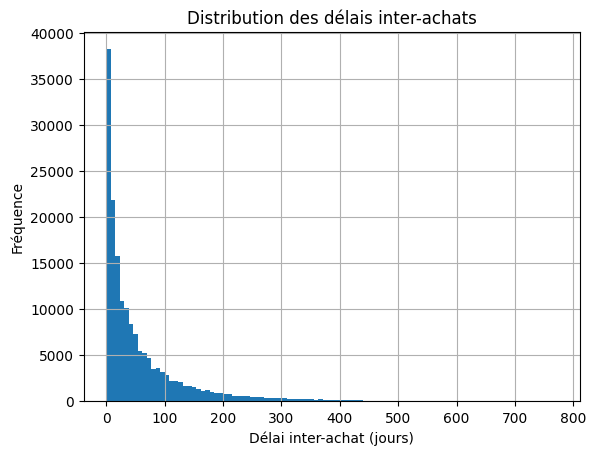

In [112]:
import matplotlib.pyplot as plt

plt.figure()
interpurchase["interpurchase_days"].hist(bins=100)
plt.xlabel("Délai inter-achat (jours)")
plt.ylabel("Fréquence")
plt.title("Distribution des délais inter-achats")
plt.show()

In [113]:
print(interpurchase["interpurchase_days"].quantile([0.5,0.75,0.9,0.95,0.99]))

0.50     29.0
0.75     76.0
0.90    156.0
0.95    224.0
0.99    377.0
Name: interpurchase_days, dtype: float64


.5 Proposition du seuil de churn

In [114]:
churn_threshold = interpurchase["interpurchase_days"].quantile(0.9)
print("Seuil churn proposé:", churn_threshold)

Seuil churn proposé: 156.0


Le ratio 
𝑃
90
/
𝑀
𝑒
ˊ
𝑑
𝑖
𝑎
𝑛
𝑒
=
156
/
29
≈
5.4
P90/M
e
ˊ
diane=156/29≈5.4

Cela confirme :

Présence de clients très saisonniers

Hétérogénéité comportementale marquée

Distribution clairement right-skewed

La moyenne (non fournie ici mais très probablement > 29) est tirée vers le haut par ces cas extrêmes.

1.6 Calcul de la récence actuelle

In [115]:
last_purchase = (
    orders.groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_purchase["recency_days"] = (
    (snapshot_date - last_purchase["order_date"]).dt.days
)

1.7 Labellisation churn

In [116]:
last_purchase["churn"] = (
    last_purchase["recency_days"] > churn_threshold
).astype(int)

print(last_purchase["churn"].value_counts(normalize=True))

churn
1    0.627608
0    0.372392
Name: proportion, dtype: float64


Ce déséquilibre conditionnera l’Étape 3 (class_weight, SMOTE, StratifiedKFold).

2.1 Construction des agrégats transactionnels

In [117]:
# Montant par ligne
df["line_amount"] = df["quantity"] * df["unit_price"]

# Niveau commande
orders = (
    df.groupby(["customer_id","invoice_id"], as_index=False)
      .agg(
          order_date=("invoice_date","min"),
          order_amount=("line_amount","sum")
      )
)

orders = orders.sort_values(["customer_id","order_date"])
print("df:", df.shape)
print("orders:", orders.shape)
display(orders.head())

df: (1356872, 9)
orders: (218482, 4)


,customer_id,invoice_id,order_date,order_amount
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


2.2 Features RFM (niveau comportemental de base)

In [118]:
rfm = orders.groupby("customer_id").agg(
    last_order=("order_date","max"),
    first_order=("order_date","min"),
    frequency=("invoice_id","count"),
    monetary=("order_amount","sum")
).reset_index()

rfm["recency_days"] = (snapshot_date - rfm["last_order"]).dt.days
rfm["customer_age_days"] = (snapshot_date - rfm["first_order"]).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

print("rfm:", rfm.shape)
display(rfm.head())

rfm: (48849, 8)


,customer_id,last_order,first_order,frequency,monetary,recency_days,customer_age_days,avg_order_value
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,325,725,6463.038333
1,12347,2011-12-07 15:52:00,2010-10-31 14:20:00,8,4921.53,1,403,615.19125
2,12348,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.4,74,437,403.88
3,12349,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,18,588,1107.1725
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4,309,309,334.4


2.3 Tendance de la fréquence

In [119]:
orders["order_rank"] = orders.groupby("customer_id").cumcount() + 1
orders["total_orders"] = orders.groupby("customer_id")["invoice_id"].transform("count")

# Séparation première moitié / seconde moitié
orders["period"] = np.where(
    orders["order_rank"] <= orders["total_orders"] / 2,
    "early",
    "late"
)

freq_trend = (
    orders.groupby(["customer_id","period"])
          .size()
          .unstack(fill_value=0)
          .reset_index()
)

freq_trend["frequency_trend"] = (
    freq_trend["late"] - freq_trend["early"]
)

rfm = rfm.merge(freq_trend[["customer_id","frequency_trend"]],
                on="customer_id",
                how="left")
print("freq_trend:", freq_trend.shape)
display(freq_trend.head())
print("rfm cols:", rfm.columns.tolist())

freq_trend: (48849, 4)


period,customer_id,early,late,frequency_trend
0,12346,6,6,0
1,12347,4,4,0
2,12348,2,3,1
3,12349,2,2,0
4,12350,0,1,1


rfm cols: ['customer_id', 'last_order', 'first_order', 'frequency', 'monetary', 'recency_days', 'customer_age_days', 'avg_order_value', 'frequency_trend']


2.4 Tendance du montant

In [120]:
amount_trend = (
    orders.groupby(["customer_id","period"])
          ["order_amount"]
          .mean()
          .unstack()
          .reset_index()
)

amount_trend["amount_trend"] = (
    amount_trend["late"] - amount_trend["early"]
)

rfm = rfm.merge(
    amount_trend[["customer_id","amount_trend"]],
    on="customer_id",
    how="left"
)
print("amount_trend:", amount_trend.shape)
display(amount_trend.head())

amount_trend: (48849, 4)


period,customer_id,early,late,amount_trend
0,12346,22.666667,12903.41,12880.743333
1,12347,608.74,621.6425,12.9025
2,12348,557.48,301.48,-256.0
3,12349,634.26,1580.085,945.825
4,12350,<NA>,334.4,<NA>


2.5 Récence relative

In [121]:
# délai moyen inter-achat par client
orders["prev_date"] = orders.groupby("customer_id")["order_date"].shift(1)
orders["gap"] = (orders["order_date"] - orders["prev_date"]).dt.days

avg_gap = (
    orders.groupby("customer_id")["gap"]
    .mean()
    .reset_index()
    .rename(columns={"gap":"avg_gap_days"})
)

rfm = rfm.merge(avg_gap, on="customer_id", how="left")

rfm["relative_recency"] = rfm["recency_days"] / rfm["avg_gap_days"]


2.6 Nombre de mois sans achat (6 derniers mois)

In [122]:
# 2.6 Nombre de mois sans achat (6 derniers mois)

six_months_ago = snapshot_date - pd.DateOffset(months=6)
recent_orders = orders[orders["order_date"] >= six_months_ago]

monthly_activity = (
    recent_orders
    .assign(month=recent_orders["order_date"].dt.to_period("M"))
    .groupby(["customer_id", "month"])
    .size()
    .groupby("customer_id")
    .size()
    .reset_index(name="active_months_6m")
)

# éviter collision de colonnes
if "active_months_6m" in rfm.columns:
    rfm = rfm.drop(columns=["active_months_6m"])

rfm = rfm.merge(monthly_activity, on="customer_id", how="left")

rfm["active_months_6m"] = rfm["active_months_6m"].fillna(0).astype(int)
rfm["inactive_months_6m"] = 6 - rfm["active_months_6m"]

print(rfm[["active_months_6m","inactive_months_6m"]].head(10))
print(rfm[["active_months_6m","inactive_months_6m"]].describe())

   active_months_6m  inactive_months_6m
0                 0                   6
1                 4                   2
2                 1                   5
3                 1                   5
4                 0                   6
5                 0                   6
6                 2                   4
7                 0                   6
8                 0                   6
9                 0                   6
       active_months_6m  inactive_months_6m
count      48849.000000        48849.000000
mean           0.744867            5.255133
std            1.193124            1.193124
min            0.000000           -1.000000
25%            0.000000            5.000000
50%            0.000000            6.000000
75%            1.000000            6.000000
max            7.000000            6.000000


2.7 Ratio dernière commande / panier moyen historique

In [123]:
last_amount = (
    orders.sort_values("order_date")
          .groupby("customer_id")
          .tail(1)
          [["customer_id","order_amount"]]
          .rename(columns={"order_amount":"last_order_amount"})
)

rfm = rfm.merge(last_amount, on="customer_id", how="left")

rfm["last_vs_avg_ratio"] = (
    rfm["last_order_amount"] / rfm["avg_order_value"]
)
print(rfm[["last_order_amount","avg_order_value","last_vs_avg_ratio"]].head(10))
print("NaN last_vs_avg_ratio:", rfm["last_vs_avg_ratio"].isna().mean())



   last_order_amount  avg_order_value  last_vs_avg_ratio
0            77183.6      6463.038333          11.942309
1             224.82        615.19125           0.365447
2              310.0           403.88           0.767555
3            1757.55        1107.1725           1.587422
4              334.4            334.4                1.0
5             300.93           300.93                1.0
6             311.73       223.282222           1.396125
7               89.0           203.38           0.437604
8             1079.4           1079.4                1.0
9              459.4          473.805           0.969597
NaN last_vs_avg_ratio: 0.0


2.8 Intégration de la cible churn

In [124]:
rfm = rfm.merge(
    last_purchase[["customer_id","churn"]],
    on="customer_id",
    how="left"
)
print("Churn distribution:")
print(rfm["churn"].value_counts(dropna=False))
print("NaN churn:", rfm["churn"].isna().mean())

Churn distribution:
churn
1    30658
0    18191
Name: count, dtype: int64
NaN churn: 0.0


2.9 Vérifications méthodologiques obligatoires

In [125]:
print(rfm.isna().mean().sort_values(ascending=False).head())
print(rfm.describe())

avg_gap_days        0.417552
amount_trend        0.417552
relative_recency    0.417552
customer_id         0.000000
last_order          0.000000
dtype: float64
        customer_id                  last_order                 first_order  \
count       48849.0                       48849                       48849   
mean   37869.956253  2010-12-15 10:15:59.299883  2010-05-24 01:16:29.903580   
min         12346.0         2007-07-06 12:20:00         2007-07-06 12:20:00   
25%         24936.0         2010-05-22 12:20:00         2009-11-20 12:20:00   
50%         37926.0         2011-03-15 12:20:00         2010-04-29 19:07:00   
75%         50772.0         2011-09-13 12:20:00         2010-12-21 12:20:00   
max         63441.0         2011-12-09 12:50:00         2011-12-09 12:20:00   
std     14846.60821                         NaN                         NaN   

          frequency     monetary  recency_days  customer_age_days  \
count  48849.000000      48849.0  48849.000000       48849.

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [126]:
single_purchase = rfm[rfm["frequency"] == 1].shape[0]
total_clients = rfm.shape[0]

print("Clients 1 achat:", single_purchase)
print("Proportion:", single_purchase / total_clients)

Clients 1 achat: 20397
Proportion: 0.4175520481483756


In [127]:
rfm_model = rfm[rfm["frequency"] >= 2].copy()

print("N clients récurrents:", rfm_model.shape[0])
print("Churn distribution (récurrents):")
print(rfm_model["churn"].value_counts(normalize=True))

N clients récurrents: 28452
Churn distribution (récurrents):
churn
1    0.512126
0    0.487874
Name: proportion, dtype: float64


3.1 Préparation des données (X, y) + split

In [128]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# ====== Dataset de modélisation ======
# rfm_model doit exister (créé à la fin Étape 2)
y = rfm_model["churn"].astype(int)

# Colonnes à exclure (identifiants / dates)
drop_cols = ["customer_id", "churn", "first_order", "last_order"]
X = rfm_model.drop(columns=[c for c in drop_cols if c in rfm_model.columns]).copy()

# Sélection des colonnes numériques (notre feature set est numérique ici)
num_cols = X.columns.tolist()

# Split stratifié pour garder la proportion churn stable train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Churn rate train:", y_train.mean(), "test:", y_test.mean())

Train: (22761, 13) Test: (5691, 13)
Churn rate train: 0.5121040376081895 test: 0.5122122649797927


In [129]:
# ===== Sanity check + nettoyage robuste =====
# 1) Forcer toutes les colonnes en numérique quand possible
X = X.apply(pd.to_numeric, errors="coerce")

# 2) Remplacer toutes les valeurs non-finies (inf, -inf) par NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 3) Vérifier qu'il ne reste aucune valeur non-finie
nonfinite_cols = X.columns[~np.isfinite(X.to_numpy(dtype=float)).all(axis=0)]
print("Colonnes avec valeurs non-finies après nettoyage:", list(nonfinite_cols))

# 4) Vérifier valeurs extrêmes (peuvent causer 'too large')
max_abs = np.nanmax(np.abs(X.to_numpy(dtype=float)))
print("Max abs value in X:", max_abs)

# Option: clip léger pour éviter explosions numériques (justification : robustesse)
# On ne transforme pas la distribution "à l'aveugle": on clip seulement des extrêmes pathologiques
X = X.clip(lower=-1e6, upper=1e6)

Colonnes avec valeurs non-finies après nettoyage: ['relative_recency']
Max abs value in X: 580987.04


In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

3.3 Baseline — Régression logistique (class_weight='balanced') + CV stratifiée

In [131]:
from sklearn.metrics import make_scorer

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "avg_precision": "average_precision"
}

cv_results = cross_validate(
    baseline, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("CV ROC-AUC:", cv_results["test_roc_auc"].mean(), "+/-", cv_results["test_roc_auc"].std())
print("CV F1:", cv_results["test_f1"].mean(), "+/-", cv_results["test_f1"].std())
print("CV AvgPrecision (PR-AUC):", cv_results["test_avg_precision"].mean(), "+/-", cv_results["test_avg_precision"].std())

CV ROC-AUC: 0.9998470288548699 +/- 4.988566011424007e-05
CV F1: 0.9960830281825022 +/- 0.0006617667300204894
CV AvgPrecision (PR-AUC): 0.9998592169199899 +/- 4.486461543067496e-05


In [132]:
baseline.fit(X_train, y_train)

proba_test = baseline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("ROC-AUC test:", roc_auc_score(y_test, proba_test))
print("F1 test:", f1_score(y_test, pred_test))
print(classification_report(y_test, pred_test))

ROC-AUC test: 0.999935615740901
F1 test: 0.9972499140598143
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2776
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5691
   macro avg       1.00      1.00      1.00      5691
weighted avg       1.00      1.00      1.00      5691



3.4 Courbe Precision–Recall (obligatoire)

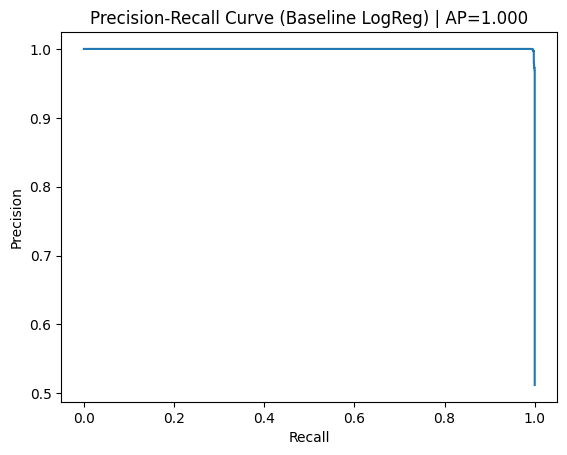

In [133]:
prec, rec, thr = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Baseline LogReg) | AP={ap:.3f}")
plt.show()

3.5 Stratégie alternative de rééquilibrage — SMOTE (comparaison)

In [134]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

baseline_smote = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("model", LogisticRegression(max_iter=2000))
])

cv_results_smote = cross_validate(
    baseline_smote, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("SMOTE CV ROC-AUC:", cv_results_smote["test_roc_auc"].mean(), "+/-", cv_results_smote["test_roc_auc"].std())
print("SMOTE CV F1:", cv_results_smote["test_f1"].mean(), "+/-", cv_results_smote["test_f1"].std())
print("SMOTE CV AvgPrecision:", cv_results_smote["test_avg_precision"].mean(), "+/-", cv_results_smote["test_avg_precision"].std())

SMOTE CV ROC-AUC: 0.9998524370692271 +/- 4.742856319023381e-05
SMOTE CV F1: 0.9961692149916244 +/- 0.0007166140177979094
SMOTE CV AvgPrecision: 0.9998639656959956 +/- 4.2745171617576946e-05


In [135]:
baseline_smote.fit(X_train, y_train)
proba_test_sm = baseline_smote.predict_proba(X_test)[:, 1]
pred_test_sm = (proba_test_sm >= 0.5).astype(int)

print("ROC-AUC test (SMOTE):", roc_auc_score(y_test, proba_test_sm))
print("F1 test (SMOTE):", f1_score(y_test, pred_test_sm))
print(classification_report(y_test, pred_test_sm))

ROC-AUC test (SMOTE): 0.9999357393191333
F1 test (SMOTE): 0.9974231231747123
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2776
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5691
   macro avg       1.00      1.00      1.00      5691
weighted avg       1.00      1.00      1.00      5691



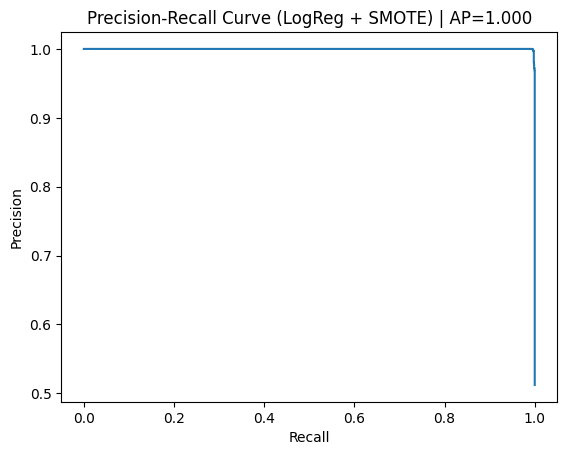

In [136]:
prec_sm, rec_sm, _ = precision_recall_curve(y_test, proba_test_sm)
ap_sm = average_precision_score(y_test, proba_test_sm)

plt.figure()
plt.plot(rec_sm, prec_sm)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (LogReg + SMOTE) | AP={ap_sm:.3f}")
plt.show()

3.6 Choix du seuil de décision selon le contexte métier

In [137]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 181)
f1s = []

for t in thresholds:
    f1s.append(f1_score(y_test, (proba_test >= t).astype(int)))

best_idx = int(np.argmax(f1s))
best_t = thresholds[best_idx]
print("Best threshold (max F1):", best_t, "F1:", f1s[best_idx])

Best threshold (max F1): 0.4599999999999999 F1: 0.9974257765574052


3.7 Modèle principal — LightGBM ou XGBoost (au choix)

In [138]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight="balanced"
)

lgbm_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgbm)
])

cv_results_lgbm = cross_validate(
    lgbm_pipe, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("LGBM CV ROC-AUC:", cv_results_lgbm["test_roc_auc"].mean(), "+/-", cv_results_lgbm["test_roc_auc"].std())
print("LGBM CV F1:", cv_results_lgbm["test_f1"].mean(), "+/-", cv_results_lgbm["test_f1"].std())
print("LGBM CV AvgPrecision:", cv_results_lgbm["test_avg_precision"].mean(), "+/-", cv_results_lgbm["test_avg_precision"].std())

[LightGBM] [Info] Number of positive: 9324, number of negative: 8884
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002017 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2402
[LightGBM] [Info] Number of data points in the train set: 18208, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 8884
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001750 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2406
[LightGBM] [Info] Number of data points in the train set: 18209, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 8884
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2404
[LightGBM] [Info] Number of data points in the train set: 18209, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 8884
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2409
[LightGBM] [Info] Number of data points in the train set: 18209, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 8884
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2404
[LightGBM] [Info] Number of data points in the train set: 18209, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 11656, number of negative: 11105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2413
[LightGBM] [Info] Number of data points in the train set: 22761, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC test (LGBM): 0.9999959219183296
F1 test (LGBM): 0.9982870846180198
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2776
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5691
   macro avg       1.00      1.00      1.00      5691
weighted avg       1.00      1.00      1.00      5691



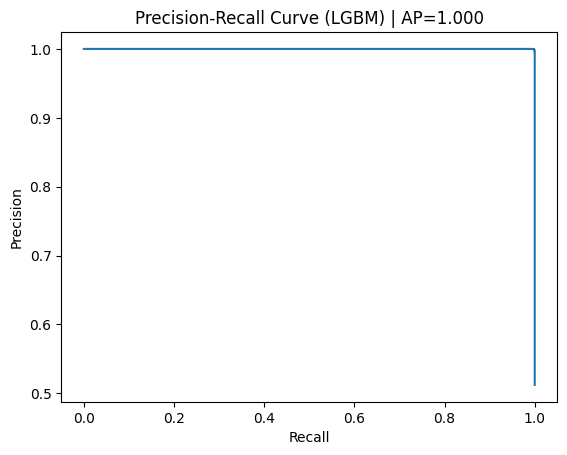

In [139]:
lgbm_pipe.fit(X_train, y_train)
proba_lgbm = lgbm_pipe.predict_proba(X_test)[:, 1]
pred_lgbm = (proba_lgbm >= 0.5).astype(int)

print("ROC-AUC test (LGBM):", roc_auc_score(y_test, proba_lgbm))
print("F1 test (LGBM):", f1_score(y_test, pred_lgbm))
print(classification_report(y_test, pred_lgbm))

prec_l, rec_l, _ = precision_recall_curve(y_test, proba_lgbm)
ap_l = average_precision_score(y_test, proba_lgbm)

plt.figure()
plt.plot(rec_l, prec_l)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (LGBM) | AP={ap_l:.3f}")
plt.show()

In [140]:
lgbm_smote = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

cv_results_lgbm_smote = cross_validate(
    lgbm_smote, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("LGBM+SMOTE CV ROC-AUC:", cv_results_lgbm_smote["test_roc_auc"].mean(), "+/-", cv_results_lgbm_smote["test_roc_auc"].std())
print("LGBM+SMOTE CV F1:", cv_results_lgbm_smote["test_f1"].mean(), "+/-", cv_results_lgbm_smote["test_f1"].std())
print("LGBM+SMOTE CV AvgPrecision:", cv_results_lgbm_smote["test_avg_precision"].mean(), "+/-", cv_results_lgbm_smote["test_avg_precision"].std())

[LightGBM] [Info] Number of positive: 9324, number of negative: 9324
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002043 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 18648, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 9325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2885
[LightGBM] [Info] Number of data points in the train set: 18650, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 9325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2732
[LightGBM] [Info] Number of data points in the train set: 18650, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 9325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2730
[LightGBM] [Info] Number of data points in the train set: 18650, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 9325, number of negative: 9325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2706
[LightGBM] [Info] Number of data points in the train set: 18650, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\33766\OneDrive\Bureau\TP4\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [141]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

hgb = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=None,
    random_state=42
)

hgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", hgb)
])

hgb_pipe.fit(X_train, y_train)

proba_test = hgb_pipe.predict_proba(X_test)[:,1]

print("ROC-AUC test:", roc_auc_score(y_test, proba_test))

ROC-AUC test: 1.0


In [142]:
!pip install shap


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


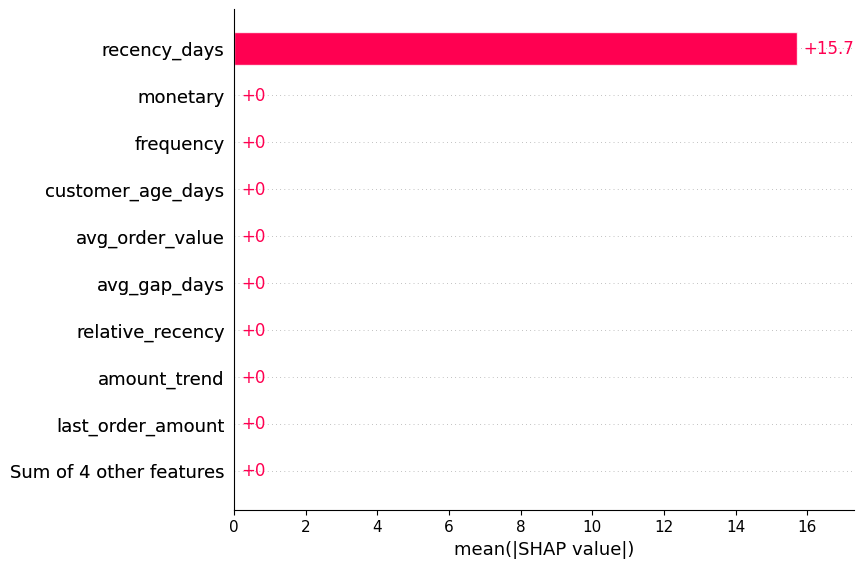

In [143]:
import shap

# Extraire le modèle interne
model = hgb_pipe.named_steps["model"]

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=10)

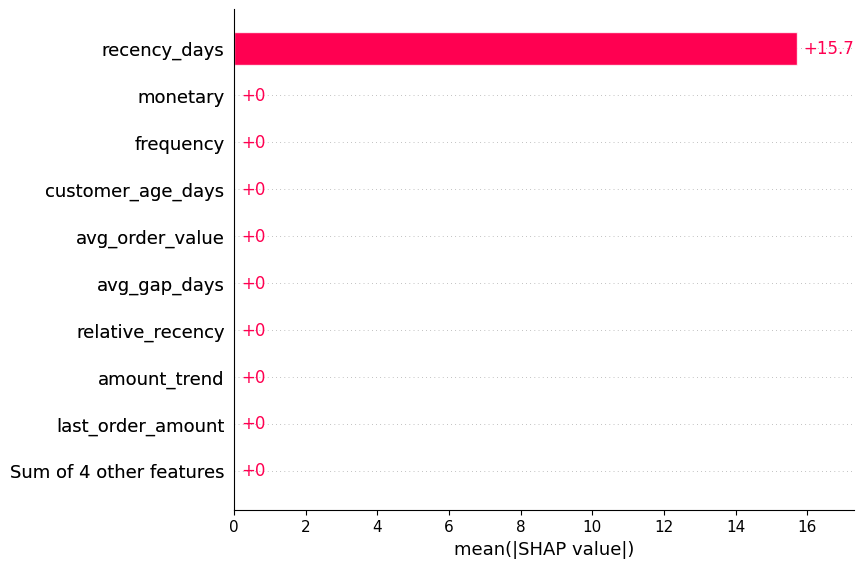

In [144]:
shap.plots.bar(shap_values, max_display=10)

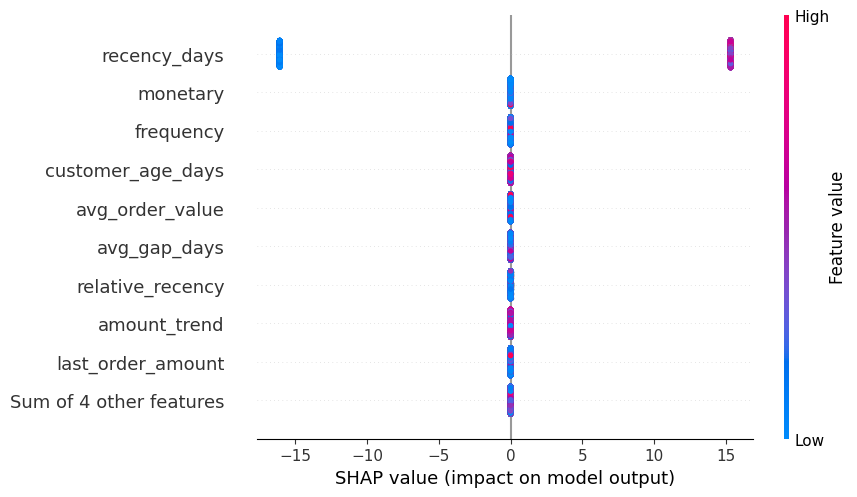

In [145]:
shap.plots.beeswarm(shap_values, max_display=10)

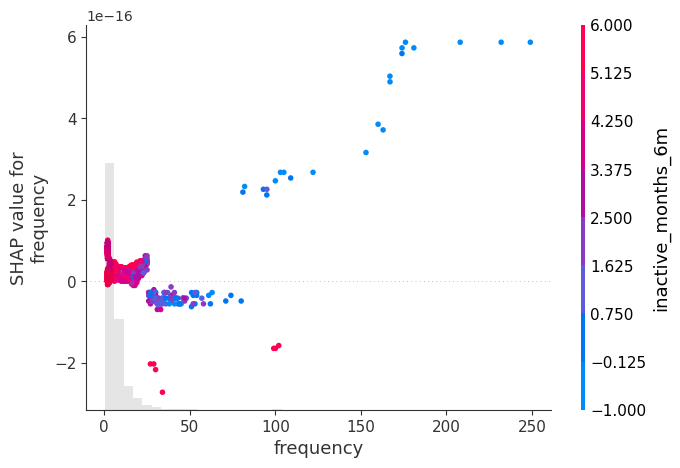

In [146]:
shap.plots.scatter(shap_values[:, "frequency"], color=shap_values[:, "inactive_months_6m"])

5.1 Scoring churn sur tous les clients récurrents

In [147]:
rfm_model["churn_proba"] = hgb_pipe.predict_proba(X)[:,1]

In [148]:
rfm_model["clv_pred"] = (
    rfm_model["avg_order_value"] *
    rfm_model["frequency"]
)

In [149]:
clv_threshold = rfm_model["clv_pred"].median()
rfm_model["clv_segment"] = np.where(
    rfm_model["clv_pred"] >= clv_threshold,
    "High",
    "Low"
)

In [150]:
churn_threshold_model = 0.455  # ton best threshold F1

rfm_model["risk_segment"] = np.where(
    rfm_model["churn_proba"] >= churn_threshold_model,
    "High",
    "Low"
)

In [151]:
rfm_model["quadrant"] = (
    rfm_model["clv_segment"] + "_" +
    rfm_model["risk_segment"]
)

print(rfm_model["quadrant"].value_counts())

quadrant
Low_High     9104
High_Low     8759
High_High    5467
Low_Low      5122
Name: count, dtype: int64


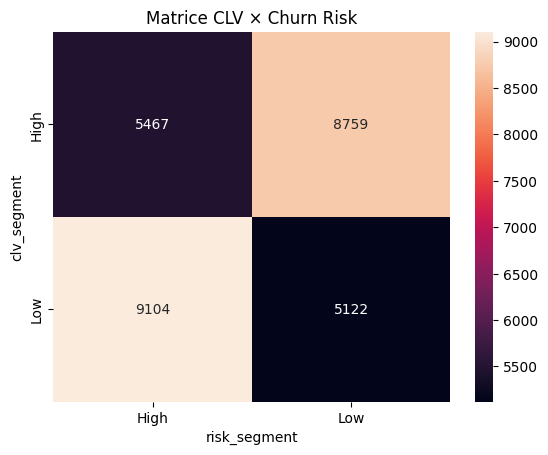

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = (
    rfm_model.groupby(["clv_segment","risk_segment"])
    .size()
    .unstack()
)

plt.figure()
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Matrice CLV × Churn Risk")
plt.show()

In [153]:
q1 = rfm_model[
    (rfm_model["clv_segment"]=="High") &
    (rfm_model["risk_segment"]=="High")
]

print("Clients Q1:", q1.shape[0])

Clients Q1: 5467


In [154]:
q1["budget_max"] = q1["clv_pred"] * 0.20
total_budget = q1["budget_max"].sum()

print("Budget total justifiable:", total_budget)

Budget total justifiable: 1045337.0544


In [155]:
roi = q1["clv_pred"].sum() * 0.20
print("ROI attendu:", roi)

ROI attendu: 1045337.0544
